<a href="https://colab.research.google.com/github/saranyasa-siza/AI-ML/blob/main/1st_BasicData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***BREAST CANCER***

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datas/brca.csv')
df.head()

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


In [ ]:
df.columns

Index(['Unnamed: 0', 'x.radius_mean', 'x.texture_mean', 'x.perimeter_mean',
       'x.area_mean', 'x.smoothness_mean', 'x.compactness_mean',
       'x.concavity_mean', 'x.concave_pts_mean', 'x.symmetry_mean',
       'x.fractal_dim_mean', 'x.radius_se', 'x.texture_se', 'x.perimeter_se',
       'x.area_se', 'x.smoothness_se', 'x.compactness_se', 'x.concavity_se',
       'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se',
       'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst',
       'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst',
       'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst',
       'x.fractal_dim_worst', 'y'],
      dtype='object')

In [ ]:
df.shape

(569, 32)

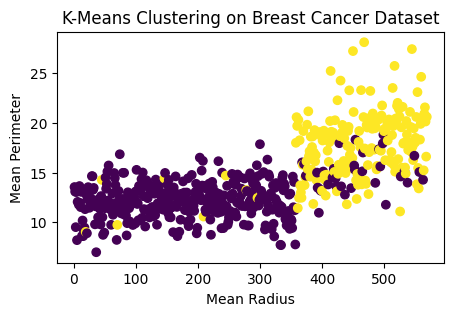

In [ ]:
# Clustering [unsupervised learning]

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datas/brca.csv')
df.head()

X = df.iloc[:, :-1]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=100)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters
df.head()

plt.figure(figsize=(5,3))
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=clusters)
plt.xlabel("Mean Radius")
plt.ylabel("Mean Perimeter")
plt.title("K-Means Clustering on Breast Cancer Dataset")
plt.show()

In [ ]:
# Classification [supervised learning]

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import GaussianNB

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datas/brca.csv')
df.head()

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model  = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.956140350877193

Confusion Matrix:
 [[71  0]
 [ 5 38]]

Classification Report:
               precision    recall  f1-score   support

           B       0.93      1.00      0.97        71
           M       1.00      0.88      0.94        43

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



***DERMATOLOGY***

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datas/dermatology_database_1.csv')
df.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3


In [ ]:
df.columns

Index(['erythema', 'scaling', 'definite_borders', 'itching',
       'koebner_phenomenon', 'polygonal_papules', 'follicular_papules',
       'oral_mucosal_involvement', 'knee_and_elbow_involvement',
       'scalp_involvement', 'family_history', 'melanin_incontinence',
       'eosinophils_infiltrate', 'PNL_infiltrate', 'fibrosis_papillary_dermis',
       'exocytosis', 'acanthosis', 'hyperkeratosis', 'parakeratosis',
       'clubbing_rete_ridges', 'elongation_rete_ridges',
       'thinning_suprapapillary_epidermis', 'spongiform_pustule',
       'munro_microabcess', 'focal_hypergranulosis',
       'disappearance_granular_layer', 'vacuolisation_damage_basal_layer',
       'spongiosis', 'saw_tooth_appearance_retes', 'follicular_horn_plug',
       'perifollicular_parakeratosis', 'inflammatory_mononuclear_infiltrate',
       'band_like_infiltrate', 'age', 'class'],
      dtype='object')

(366, 35)


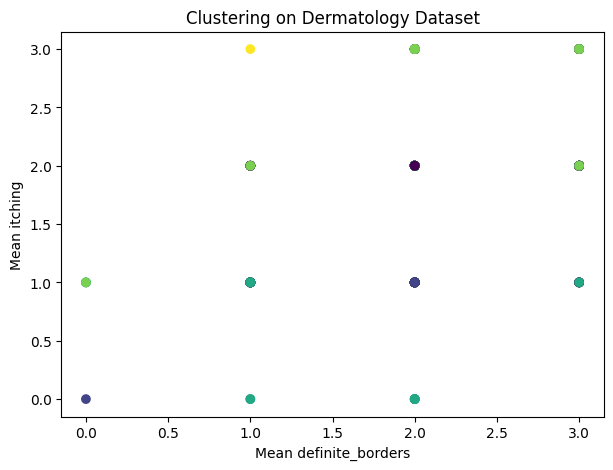

In [ ]:
# Clustering

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datas/dermatology_database_1.csv')
print(df.shape)
df.head()

df = df.apply(pd.to_numeric, errors='coerce')
df = df.fillna(df.mean())

X = df.iloc[:, :-1]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=6, random_state=100)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters
df.head()

plt.figure(figsize=(7,5))
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=clusters)
plt.xlabel("Mean definite_borders")
plt.ylabel("Mean itching")
plt.title("Clustering on Dermatology Dataset")
plt.show()

In [ ]:
# Classification

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import GaussianNB

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datas/dermatology_database_1.csv')
print(df.shape)
df.head()

df = df.apply(pd.to_numeric, errors='coerce')
df = df.fillna(df.mean())

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model  = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

(366, 35)
Accuracy: 0.9054054054054054

Confusion Matrix:
 [[31  0  0  0  0  0]
 [ 0  3  0  4  2  0]
 [ 0  0 13  0  0  0]
 [ 0  0  0  8  0  0]
 [ 0  1  0  0  9  0]
 [ 0  0  0  0  0  3]]

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        31
           2       0.75      0.33      0.46         9
           3       1.00      1.00      1.00        13
           4       0.67      1.00      0.80         8
           5       0.82      0.90      0.86        10
           6       1.00      1.00      1.00         3

    accuracy                           0.91        74
   macro avg       0.87      0.87      0.85        74
weighted avg       0.91      0.91      0.89        74



***WINE***

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datas/wine.data') # Corrected path
df.to_csv('wine.csv', index=False)
df.head()

,1,14.23,1.71,2.43,15.6,127,2.8,3.06,.28,2.29,5.64,1.04,3.92,1065
0,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
1,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
2,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
3,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
4,1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450


In [ ]:
df.columns

Index(['1', '14.23', '1.71', '2.43', '15.6', '127', '2.8', '3.06', '.28',
       '2.29', '5.64', '1.04', '3.92', '1065'],
      dtype='object')

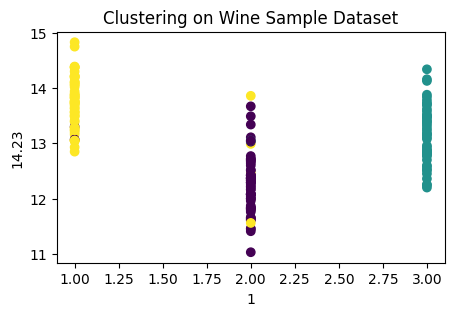

In [ ]:
# Clustering

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datas/wine.data')
df.to_csv('wine.csv', index=False)
df.head()

X = df.iloc[:, :-1]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=100)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters
df.head()

plt.figure(figsize=(5,3))
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=clusters)
plt.xlabel("1")
plt.ylabel("14.23")
plt.title("Clustering on Wine Sample Dataset")
plt.show()

In [ ]:
# Classification

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import GaussianNB

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datas/wine.data')
df.to_csv('wine.csv', index=False)
df.head()

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model  = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.027777777777777776

Confusion Matrix:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

Classification Report:
               precision    recall  f1-score   support

         342       0.00      0.00      0.00         1
         372       0.00      0.00      0.00         1
         385       0.00      0.00      0.00         1
         407       0.00      0.00      0.00         1
         450       0.00      0.00      0.00         2
         470       0.00      0.00      0.00         1
         480       0.00      0.00      0.00         1
         495       0.00      0.00      0.00         0
         500       0.00      0.00      0.00         0
         502       0.00      0.00      0.00         1
         510       0.00      0.00      0.00         1
         515       0.00      0.00      0.00         1
         520       0.00      0.00      0.00         0
         562       0.00      0.00      0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

***SPECFT HEART***

In [ ]:
import pandas as pd

files = [
    '/content/drive/MyDrive/Colab Notebooks/datas/spect_test.csv',
    '/content/drive/MyDrive/Colab Notebooks/datas/spect_test_binary.csv',
    '/content/drive/MyDrive/Colab Notebooks/datas/spect_train.csv',
    '/content/drive/MyDrive/Colab Notebooks/datas/spect_train_binary.csv'
]

dfs = [pd.read_csv(f) for f in files]

df1, df2, df3, df4=dfs
df1.head()

,OVERALL_DIAGNOSIS,F1R,F1S,F2R,F2S,F3R,F3S,F4R,F4S,F5R,...,F18R,F18S,F19R,F19S,F20R,F20S,F21R,F21S,F22R,F22S
0,1,67,68,73,78,65,63,67,60,63,...,61,56,76,75,74,77,76,74,59,68
1,1,75,74,71,71,62,58,70,64,71,...,66,62,68,69,69,66,64,58,57,52
2,1,83,64,66,67,67,74,74,72,64,...,67,64,69,63,68,54,65,64,43,42
3,1,72,66,65,65,64,61,71,78,73,...,69,68,68,63,71,72,65,63,58,60
4,1,62,60,69,61,63,63,70,68,70,...,66,66,58,56,72,73,71,64,49,42


In [ ]:
df1.columns

Index(['OVERALL_DIAGNOSIS', 'F1R', 'F1S', 'F2R', 'F2S', 'F3R', 'F3S', 'F4R',
       'F4S', 'F5R', 'F5S', 'F6R', 'F6S', 'F7R', 'F7S', 'F8R', 'F8S', 'F9R',
       'F9S', 'F10R', 'F10S', 'F11R', 'F11S', 'F12R', 'F12S', 'F13R', 'F13S',
       'F14R', 'F14S', 'F15R', 'F15S', 'F16R', 'F16S', 'F17R', 'F17S', 'F18R',
       'F18S', 'F19R', 'F19S', 'F20R', 'F20S', 'F21R', 'F21S', 'F22R', 'F22S'],
      dtype='object')

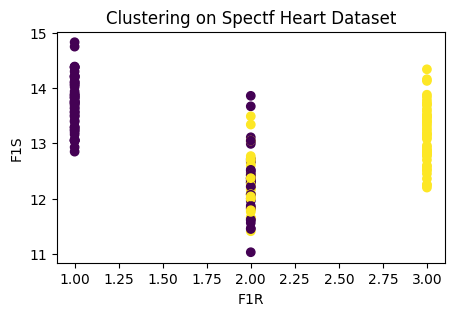

In [ ]:
# Clustering

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

files = [
    '/content/drive/MyDrive/Colab Notebooks/datas/spect_test.csv',
    '/content/drive/MyDrive/Colab Notebooks/datas/spect_test_binary.csv',
    '/content/drive/MyDrive/Colab Notebooks/datas/spect_train.csv',
    '/content/drive/MyDrive/Colab Notebooks/datas/spect_train_binary.csv'
]

dfs = [pd.read_csv(f) for f in files]

df1, df2, df3, df4=dfs
df1.head()

X = df.iloc[:, :-1]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=100)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters
df.head()

plt.figure(figsize=(5,3))
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=clusters)
plt.xlabel("F1R")
plt.ylabel("F1S")
plt.title("Clustering on Spectf Heart Dataset")
plt.show()

In [ ]:
# Classification [supervised learning]

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import GaussianNB

files = [
    '/content/drive/MyDrive/Colab Notebooks/datas/spect_test.csv',
    '/content/drive/MyDrive/Colab Notebooks/datas/spect_test_binary.csv',
    '/content/drive/MyDrive/Colab Notebooks/datas/spect_train.csv',
    '/content/drive/MyDrive/Colab Notebooks/datas/spect_train_binary.csv'
]

dfs = [pd.read_csv(f) for f in files]

df1, df2, df3, df4=dfs
df1.head()

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model  = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9444444444444444

Confusion Matrix:
 [[19  0]
 [ 2 15]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      1.00      0.95        19
           1       1.00      0.88      0.94        17

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.94        36
weighted avg       0.95      0.94      0.94        36



***REAL-WORLD WDBC***

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datas/wdbc.data') # Corrected path
df.to_csv('wdbc.csv', index=False)
df.head()

,842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,...,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
0,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
3,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
4,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440


In [ ]:
df.columns

Index(['842302', 'M', '17.99', '10.38', '122.8', '1001', '0.1184', '0.2776',
       '0.3001', '0.1471', '0.2419', '0.07871', '1.095', '0.9053', '8.589',
       '153.4', '0.006399', '0.04904', '0.05373', '0.01587', '0.03003',
       '0.006193', '25.38', '17.33', '184.6', '2019', '0.1622', '0.6656',
       '0.7119', '0.2654', '0.4601', '0.1189'],
      dtype='object')

***SEEDS***

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datas/seeds_dataset.txt') # Corrected path
df.to_csv('seeds.csv', index=False)
df.head()

,15.26\t14.84\t0.871\t5.763\t3.312\t2.221\t5.22\t1
0,14.88\t14.57\t0.8811\t5.554\t3.333\t1.018\t4.9...
1,14.29\t14.09\t0.905\t5.291\t3.337\t2.699\t4.82...
2,13.84\t13.94\t0.8955\t5.324\t3.379\t2.259\t4.8...
3,16.14\t14.99\t0.9034\t5.658\t3.562\t1.355\t5.1...
4,14.38\t14.21\t0.8951\t5.386\t3.312\t2.462\t4.9...


In [ ]:
df.columns

Index(['15.26\t14.84\t0.871\t5.763\t3.312\t2.221\t5.22\t1'], dtype='object')